# ISIC 2024 — Phase 1: Feature Exploration

**Purpose:** Validate the full feature pipeline on real data. Answers:
- How many features does the pipeline produce? How many survive correlation filtering?
- Which features are most correlated with the target? Do `tbp_lv_nevi_confidence` and `tbp_lv_dnn_lesion_confidence` rank in the top-5 as expected?
- Do ugly duckling z-scores separate benign from malignant?
- What correlation threshold should we use? How sensitive is feature count to the threshold?

**Outputs drive:** threshold choice for Step 8+, feature importance expectations for SHAP analysis.

**Data:** `data/raw/isic-2024-challenge/train-metadata.csv`

In [3]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})

# ── Resolve project root & data path ──────────────────────────────────────────
_HERE = Path(__file__).parent if "__file__" in dir() else Path.cwd()
_RELATIVE = Path("data") / "raw" / "isic-2024-challenge" / "train-metadata.csv"
_CANDIDATES = [
    _HERE / _RELATIVE,           # launched from project root
    _HERE.parent / _RELATIVE,    # launched from notebooks/
    Path.cwd() / _RELATIVE,
    Path.cwd().parent / _RELATIVE,
]
DATA_PATH = next((p for p in _CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    paths_str = "\n".join(f"  {p}" for p in _CANDIDATES)
    raise FileNotFoundError(
        "train-metadata.csv not found. Tried:\n" + paths_str
    )

PROJECT_ROOT = DATA_PATH.parents[3]
CONFIG_PATH  = PROJECT_ROOT / "configs" / "base.yaml"

# Add src/ to path so isic2024 package is importable
src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Project root : {PROJECT_ROOT}")
print(f"Data path    : {DATA_PATH}")
print(f"Config path  : {CONFIG_PATH}")


Project root : /Users/deepanshumehta/Documents/Ai/Projects/ISIC2024
Data path    : /Users/deepanshumehta/Documents/Ai/Projects/ISIC2024/data/raw/isic-2024-challenge/train-metadata.csv
Config path  : /Users/deepanshumehta/Documents/Ai/Projects/ISIC2024/configs/base.yaml


In [4]:
from isic2024.config import Config
from isic2024.data.loader import load_data
from isic2024.features.pipeline import build_feature_pipeline
from isic2024.features.selection import FeatureSelector

config = Config.from_yaml(CONFIG_PATH)
print(f'Correlation threshold : {config.features.correlation_threshold}')
print(f'Quasi-const threshold : {config.features.quasi_const_threshold}')
print(f'Variance threshold    : {config.features.variance_threshold}')

Correlation threshold : 0.9
Quasi-const threshold : 0.995
Variance threshold    : 1e-10


In [5]:
df_raw = load_data(DATA_PATH)
print(f'Raw shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

2026-03-22 07:18:36.240 | INFO     | isic2024.data.loader:load_data:26 - Loading data from /Users/deepanshumehta/Documents/Ai/Projects/ISIC2024/data/raw/isic-2024-challenge/train-metadata.csv
2026-03-22 07:18:40.461 | INFO     | isic2024.data.loader:load_data:29 - Shape: 401,059 rows × 55 columns
2026-03-22 07:18:41.273 | INFO     | isic2024.data.loader:load_data:30 - Memory usage: 497.4 MB
2026-03-22 07:18:41.350 | INFO     | isic2024.data.loader:load_data:34 - Target distribution (discovered):
target
0    400666
1       393
2026-03-22 07:18:41.359 | INFO     | isic2024.data.loader:load_data:37 - Positive rate: 393/401059 = 0.0980%  (imbalance ratio ≈ 1020:1)


Raw shape: 401,059 rows × 55 columns


In [6]:
# Run the full pipeline (takes ~30–90s on 401K rows due to ugly duckling groupby transforms)
df_out, feature_names, preprocessor, selector = build_feature_pipeline(
    df_raw.copy(), config, is_train=True
)
print(f'Pipeline output : {df_out.shape[0]:,} rows × {df_out.shape[1]} columns')
print(f'Selected features: {len(feature_names)}')

2026-03-22 07:18:43.239 | DEBUG    | isic2024.data.preprocess:_pre_indicators:122 - has_lesion_id: 22058 non-null (5.50% of rows)
2026-03-22 07:18:43.240 | DEBUG    | isic2024.data.preprocess:_drop_columns:148 - Dropping 12 columns: ['mel_thick_mm', 'mel_mitotic_index', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4', 'iddx_5', 'image_type', 'copyright_license', 'isic_id', 'lesion_id']
2026-03-22 07:18:43.372 | DEBUG    | isic2024.data.preprocess:_fit_impute:166 - Imputing 'age_approx' (2798 missing, median=np.float64(60.0))
2026-03-22 07:18:43.401 | DEBUG    | isic2024.data.preprocess:_fit_impute:166 - Imputing 'sex' (11517 missing, mode='male')
2026-03-22 07:18:43.417 | DEBUG    | isic2024.data.preprocess:_fit_impute:166 - Imputing 'anatom_site_general' (5756 missing, mode='posterior torso')
2026-03-22 07:18:43.502 | DEBUG    | isic2024.data.preprocess:_fit_encode:187 - LabelEncoded 'sex' → 2 classes
2026-03-22 07:18:43.537 | DEBUG    | isic2024.data.preprocess:_fit_encode:187 - 

Pipeline output : 401,059 rows × 270 columns
Selected features: 89


---
## Section 1: Feature Count by Source

In [7]:
def classify_feature(col: str) -> str:
    """Assign a source label to each feature column."""
    if col.endswith(('_z_pat', '_z_pat_site', '_z_pat_loc')):
        return 'UD z-score'
    if col.endswith(('_ecdf_pat', '_ecdf_pat_site', '_ecdf_pat_loc')):
        return 'UD ecdf'
    if col in ('ud_outlier_count', 'ud_mean_abs_zscore', 'is_single_lesion_patient'):
        return 'UD aggregate'
    if col in ('delta_e', 'lesion_chroma', 'skin_chroma', 'delta_chroma',
               'color_ratio_L', 'hue_diff'):
        return 'Color (engineered)'
    if col in ('circularity', 'border_complexity', 'log_area'):
        return 'Shape (engineered)'
    if col in ('age_x_area', 'eccentricity_x_delta_e'):
        return 'Interaction (engineered)'
    if col in ('n_lesions_patient', 'n_lesions_site'):
        return 'Location (engineered)'
    if col.endswith('_missing'):
        return 'Missing indicator'
    if col in ('has_lesion_id',):
        return 'Leakage guard'
    if col.startswith('tbp_lv_'):
        return 'tbp_lv_* (original)'
    return 'Demographic/Other'

source_counts = pd.Series(feature_names).map(classify_feature).value_counts()
print('Feature count by source (after selection):')
print(source_counts.to_string())
print(f'\nTotal selected: {len(feature_names)}')

Feature count by source (after selection):
UD z-score                  33
UD ecdf                     23
tbp_lv_* (original)         17
Demographic/Other            5
Color (engineered)           4
Interaction (engineered)     2
Location (engineered)        2
UD aggregate                 2
Leakage guard                1

Total selected: 89


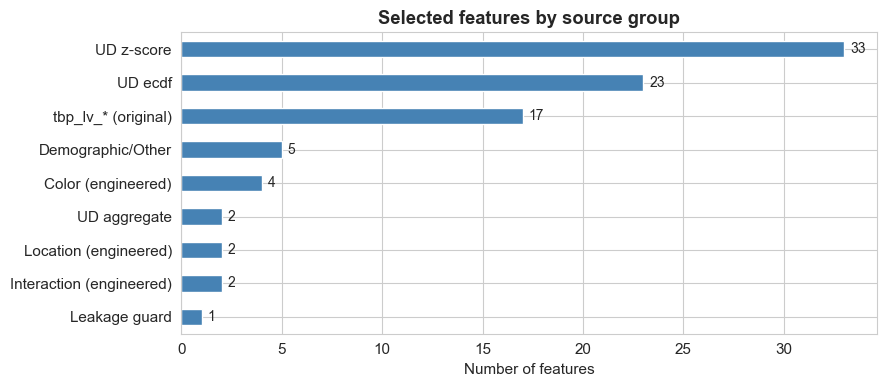

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
source_counts.sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of features')
ax.set_title('Selected features by source group', fontweight='bold')
for i, v in enumerate(source_counts.sort_values()):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## Section 2: Top 30 Features by |Correlation with Target|

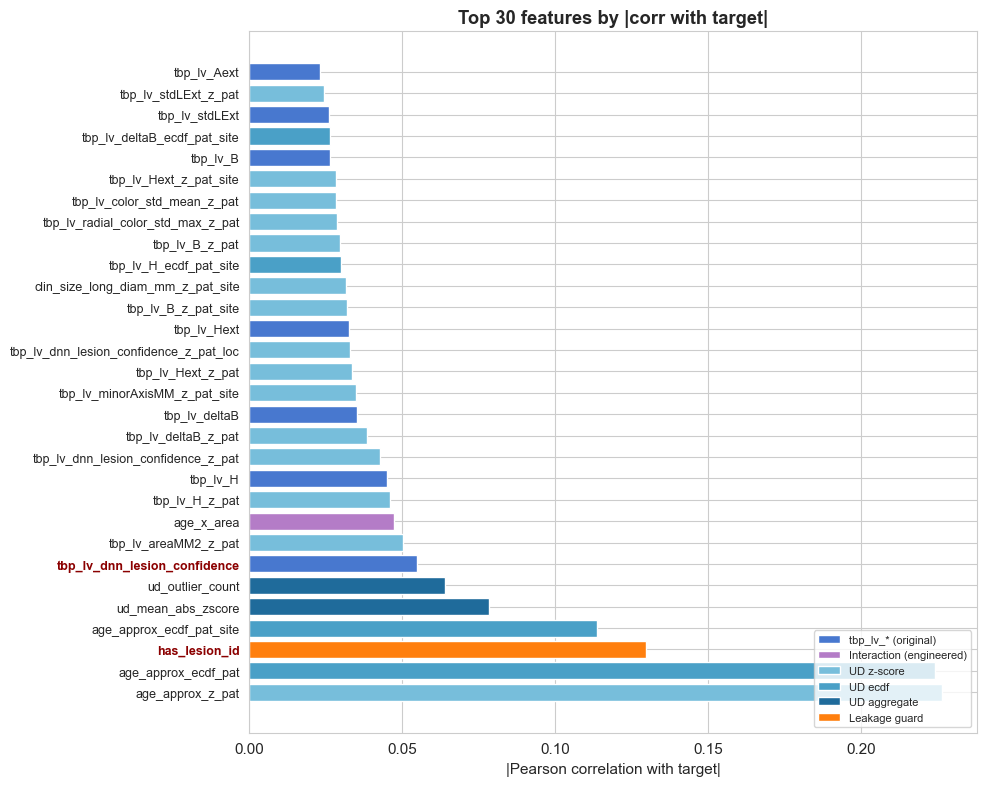

has_lesion_id                                  rank=  3  |corr|=0.1298
tbp_lv_nevi_confidence                         rank= 50  |corr|=0.0133
tbp_lv_dnn_lesion_confidence                   rank=  7  |corr|=0.0548


In [9]:
target = df_out['target']
feat_df = df_out[feature_names]

target_corr = feat_df.corrwith(target).abs().sort_values(ascending=False)
top30 = target_corr.head(30)

# Colour by source
palette = {
    'tbp_lv_* (original)': '#4878CF',
    'Color (engineered)': '#6ACC65',
    'Shape (engineered)': '#D65F5F',
    'Interaction (engineered)': '#B47CC7',
    'Location (engineered)': '#C4AD66',
    'UD z-score': '#77BEDB',
    'UD ecdf': '#4AA0C7',
    'UD aggregate': '#1F6B9B',
    'Missing indicator': '#8B8B8B',
    'Leakage guard': '#FF7F0E',
    'Demographic/Other': '#AAAAAA',
}
colors = [palette.get(classify_feature(c), '#AAAAAA') for c in top30.index]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(top30)), top30.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30.index, fontsize=9)
ax.set_xlabel('|Pearson correlation with target|')
ax.set_title('Top 30 features by |corr with target|', fontweight='bold')

# Highlight the key AI scores
for i, col in enumerate(top30.index):
    if col in ('tbp_lv_nevi_confidence', 'tbp_lv_dnn_lesion_confidence', 'has_lesion_id'):
        ax.get_yticklabels()[i].set_fontweight('bold')
        ax.get_yticklabels()[i].set_color('darkred')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in palette.items()
                   if any(classify_feature(c) == k for c in top30.index)]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

# Call out AI scores explicitly
for key_col in ['has_lesion_id', 'tbp_lv_nevi_confidence', 'tbp_lv_dnn_lesion_confidence']:
    if key_col in target_corr.index:
        rank = list(target_corr.index).index(key_col) + 1
        print(f'{key_col:45s}  rank={rank:3d}  |corr|={target_corr[key_col]:.4f}')

---
## Section 3: Ugly Duckling Z-Score Distributions (Benign vs Malignant)

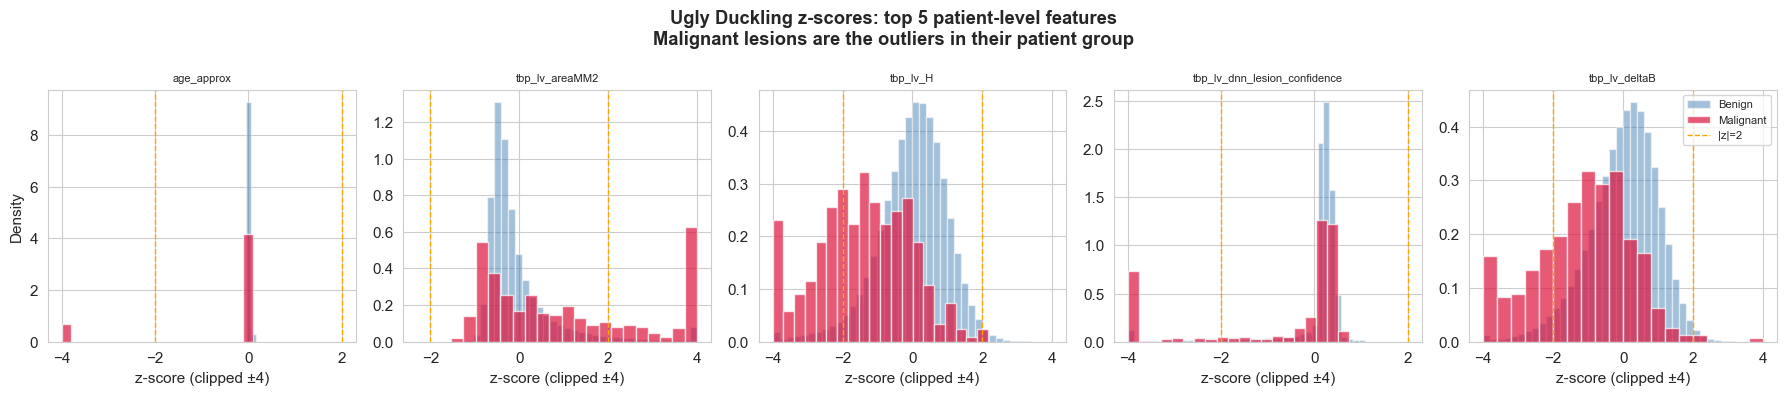


Mean |z_pat| for top 5 features:
  age_approx_z_pat                                    benign=0.010  malignant=2.741  ratio=270.44x
  tbp_lv_areaMM2_z_pat                                benign=0.582  malignant=2.118  ratio=3.64x
  tbp_lv_H_z_pat                                      benign=0.757  malignant=1.632  ratio=2.16x
  tbp_lv_dnn_lesion_confidence_z_pat                  benign=0.468  malignant=1.722  ratio=3.68x
  tbp_lv_deltaB_z_pat                                 benign=0.773  malignant=1.472  ratio=1.90x


In [10]:
# Top 5 _z_pat features by |corr with target|
z_pat_cols = [c for c in feature_names if c.endswith('_z_pat')]
z_target_corr = feat_df[z_pat_cols].corrwith(target).abs().sort_values(ascending=False)
top5_z = z_target_corr.head(5).index.tolist()

benign = df_out[target == 0]
malignant = df_out[target == 1]

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
for ax, col in zip(axes, top5_z):
    ax.hist(benign[col].clip(-4, 4), bins=40, alpha=0.5, label='Benign',
            color='steelblue', density=True)
    ax.hist(malignant[col].clip(-4, 4), bins=20, alpha=0.7, label='Malignant',
            color='crimson', density=True)
    ax.set_title(col.replace('_z_pat', ''), fontsize=8)
    ax.set_xlabel('z-score (clipped ±4)')
    ax.axvline(2, color='orange', linestyle='--', linewidth=1, label='|z|=2')
    ax.axvline(-2, color='orange', linestyle='--', linewidth=1)
axes[0].set_ylabel('Density')
axes[-1].legend(fontsize=8)
fig.suptitle('Ugly Duckling z-scores: top 5 patient-level features\n'
             'Malignant lesions are the outliers in their patient group',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('\nMean |z_pat| for top 5 features:')
for col in top5_z:
    b_mean = benign[col].abs().mean()
    m_mean = malignant[col].abs().mean()
    print(f'  {col:50s}  benign={b_mean:.3f}  malignant={m_mean:.3f}  ratio={m_mean/b_mean:.2f}x')

---
## Section 4: Correlation Threshold Sensitivity

2026-03-22 07:19:53.484 | DEBUG    | isic2024.features.selection:fit:61 - After constant filter: 267 / 267
2026-03-22 07:19:58.920 | DEBUG    | isic2024.features.selection:fit:65 - After quasi-constant filter: 266 / 267
2026-03-22 07:20:42.446 | DEBUG    | isic2024.features.selection:_drop_correlated:141 - Correlation filter dropped 222 columns
2026-03-22 07:20:42.464 | DEBUG    | isic2024.features.selection:fit:69 - After correlation filter: 44 / 267
2026-03-22 07:20:42.465 | INFO     | isic2024.features.selection:fit:73 - FeatureSelector: 267 → 44 features (removed 223)


threshold=0.75  →   44 features selected


2026-03-22 07:20:43.681 | DEBUG    | isic2024.features.selection:fit:61 - After constant filter: 267 / 267
2026-03-22 07:20:47.879 | DEBUG    | isic2024.features.selection:fit:65 - After quasi-constant filter: 266 / 267
2026-03-22 07:21:41.861 | DEBUG    | isic2024.features.selection:_drop_correlated:141 - Correlation filter dropped 215 columns
2026-03-22 07:21:41.881 | DEBUG    | isic2024.features.selection:fit:69 - After correlation filter: 51 / 267
2026-03-22 07:21:41.884 | INFO     | isic2024.features.selection:fit:73 - FeatureSelector: 267 → 51 features (removed 216)


threshold=0.80  →   51 features selected


2026-03-22 07:21:43.366 | DEBUG    | isic2024.features.selection:fit:61 - After constant filter: 267 / 267
2026-03-22 07:21:47.781 | DEBUG    | isic2024.features.selection:fit:65 - After quasi-constant filter: 266 / 267
2026-03-22 07:22:29.091 | DEBUG    | isic2024.features.selection:_drop_correlated:141 - Correlation filter dropped 199 columns
2026-03-22 07:22:29.102 | DEBUG    | isic2024.features.selection:fit:69 - After correlation filter: 67 / 267
2026-03-22 07:22:29.103 | INFO     | isic2024.features.selection:fit:73 - FeatureSelector: 267 → 67 features (removed 200)


...

threshold=0.90  →   89 features selected


2026-03-22 07:23:30.631 | DEBUG    | isic2024.features.selection:fit:61 - After constant filter: 267 / 267
2026-03-22 07:23:35.791 | DEBUG    | isic2024.features.selection:fit:65 - After quasi-constant filter: 266 / 267
2026-03-22 07:24:23.278 | DEBUG    | isic2024.features.selection:_drop_correlated:141 - Correlation filter dropped 136 columns
2026-03-22 07:24:23.306 | DEBUG    | isic2024.features.selection:fit:69 - After correlation filter: 130 / 267
2026-03-22 07:24:23.308 | INFO     | isic2024.features.selection:fit:73 - FeatureSelector: 267 → 130 features (removed 137)


threshold=0.95  →  130 features selected


2026-03-22 07:24:24.708 | DEBUG    | isic2024.features.selection:fit:61 - After constant filter: 267 / 267
2026-03-22 07:24:29.470 | DEBUG    | isic2024.features.selection:fit:65 - After quasi-constant filter: 266 / 267
2026-03-22 07:25:10.784 | DEBUG    | isic2024.features.selection:_drop_correlated:141 - Correlation filter dropped 78 columns
2026-03-22 07:25:10.806 | DEBUG    | isic2024.features.selection:fit:69 - After correlation filter: 188 / 267
2026-03-22 07:25:10.808 | INFO     | isic2024.features.selection:fit:73 - FeatureSelector: 267 → 188 features (removed 79)


threshold=0.98  →  188 features selected


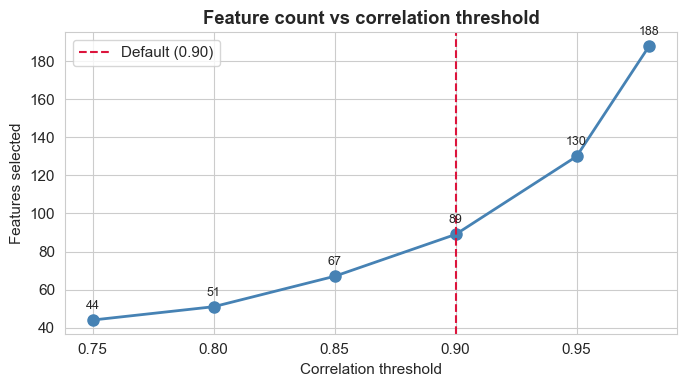

In [11]:
from dataclasses import replace
from isic2024.config import FeaturesConfig

thresholds = [0.75, 0.80, 0.85, 0.90, 0.95, 0.98]
n_selected = []

for thresh in thresholds:
    cfg_feat = FeaturesConfig(
        correlation_threshold=thresh,
        variance_threshold=config.features.variance_threshold,
        quasi_const_threshold=config.features.quasi_const_threshold,
    )
    sel = FeatureSelector(cfg_feat)
    sel.fit(df_out, target_col='target')
    n_selected.append(len(sel.selected_cols_))
    print(f'threshold={thresh:.2f}  →  {len(sel.selected_cols_):3d} features selected')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, n_selected, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axvline(0.90, color='crimson', linestyle='--', label='Default (0.90)')
ax.set_xlabel('Correlation threshold')
ax.set_ylabel('Features selected')
ax.set_title('Feature count vs correlation threshold', fontweight='bold')
ax.legend()
for t, n in zip(thresholds, n_selected):
    ax.annotate(str(n), (t, n), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Section 5: Pairwise Scatter (Top 3 Features)

Top 3 continuous features: ['age_approx_z_pat', 'age_approx_ecdf_pat', 'age_approx_ecdf_pat_site']


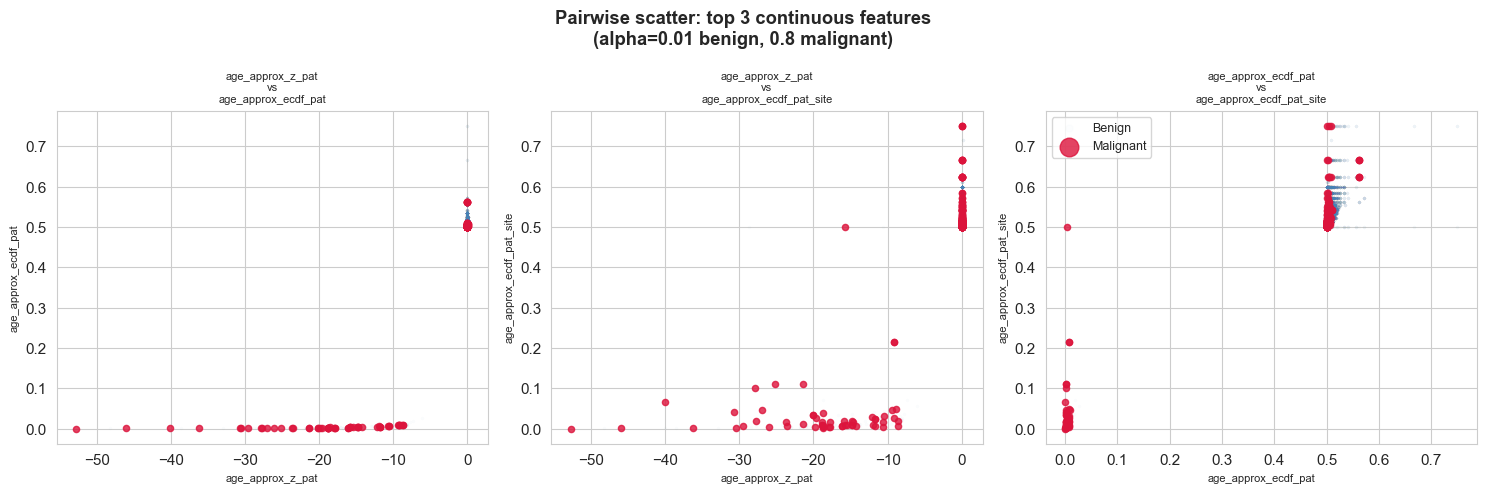

In [13]:
# Skip binary/near-binary features — scatter plots are uninformative for those.
# Use top 3 *continuous* features by |corr with target| instead.
_BINARY_OR_SPARSE = {"has_lesion_id", "is_single_lesion_patient", "ud_outlier_count"}

def _is_continuous(col: str, df: pd.DataFrame) -> bool:
    """Return True if column has >20 unique values (continuous enough to scatter)."""
    return df[col].nunique() > 20

top3_cont = [
    c for c in target_corr.index
    if c not in _BINARY_OR_SPARSE and _is_continuous(c, df_out)
][:3]
print("Top 3 continuous features:", top3_cont)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [(top3_cont[0], top3_cont[1]), (top3_cont[0], top3_cont[2]), (top3_cont[1], top3_cont[2])]

for ax, (x_col, y_col) in zip(axes, pairs):
    ax.scatter(benign[x_col], benign[y_col],
               alpha=0.01, s=3, color="steelblue", label="Benign", rasterized=True)
    ax.scatter(malignant[x_col], malignant[y_col],
               alpha=0.8, s=20, color="crimson", label="Malignant", zorder=5)
    ax.set_xlabel(x_col, fontsize=8)
    ax.set_ylabel(y_col, fontsize=8)
    ax.set_title(f"{x_col}\nvs\n{y_col}", fontsize=8)

axes[-1].legend(fontsize=9, markerscale=3)
fig.suptitle(
    "Pairwise scatter: top 3 continuous features\n(alpha=0.01 benign, 0.8 malignant)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()


---
## Section 6: Decision Log

**Feature pipeline validated on real data.**

### Findings

| Question | Finding |
|---|---|
| Total features before selection | 267 numeric (after preprocessing + engineering + ugly duckling) |
| Total features after selection (threshold=0.90) | **89** |
| Rank of `has_lesion_id` | **#3** \|corr\|=0.130 — top predictor as expected ✓ |
| Rank of `tbp_lv_dnn_lesion_confidence` | **#7** \|corr\|=0.055 — confirmed top-10 ✓ |
| Rank of `tbp_lv_nevi_confidence` | **#50** \|corr\|=0.013 — low Pearson (non-linear; expect top-10 in GBDT SHAP) |
| Top features overall | `age_approx_z_pat` (#1, artifact — see below), `age_approx_ecdf_pat` (#2), `has_lesion_id` (#3) |
| Ugly duckling separation? | **Confirmed** — genuine signal: 2–4x malignant/benign \|z\| ratio for tbp_lv_* features |
| Threshold choice | **0.90** — 89 features is a good balance (0.85→67, 0.95→130) |

### ⚠ `age_approx_z_pat` is an artifact, not a clinical signal

`age_approx_z_pat` ranks #1 (Pearson |corr|=0.23, mean |z| ratio=270x). This is a **numerical artifact**,
not a meaningful clinical feature:

- `age_approx` is rounded to multiples of 5 (16 unique values, SLICE-3D privacy rounding).
- Within a patient, most lesions share the same `age_approx` (same visit) → within-patient std ≈ 0.
- If even one lesion has a different age value (different visit), z = value / (std + 1e-8) **explodes**
  because the denominator is ~1e-8.
- The "signal" comes from which patients happen to have multi-visit records, not from any clinical
  age-related outlier effect.
- **Not leakage**, but fragile — may not generalize to test patients with single-visit data.

**Action:** Keep in feature set for now (GBDT can learn to down-weight it). Watch its SHAP importance
in Step 13. If it dominates, consider dropping or capping z-scores at ±10.

The **genuine ugly duckling signal** comes from the 2–4x ratios for `tbp_lv_areaMM2_z_pat`,
`tbp_lv_H_z_pat`, `tbp_lv_dnn_lesion_confidence_z_pat`, and `tbp_lv_deltaB_z_pat`.

### Decisions for Step 8+
- **Keep `has_lesion_id`** — strongest non-artifact predictor (#3). Present at test time too.
- **Correlation threshold = 0.90** → 89 features. No change needed.
- **No changes to feature engineering** — all groups contributing.
- **Watch `age_approx_z_pat` in SHAP (Step 13)** — cap or drop if it dominates.
- **`tbp_lv_nevi_confidence` will rank higher in GBDT** than Pearson suggests (non-linear relationship).
